In [29]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import pandas as pd

results_path = "../experiments/predictive_test_results_coef0.csv"
results_df = pd.read_csv(results_path)


In [31]:
lengths = results_df.sequence_length.unique()
lengths
results_df

,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,0.009407,2.340536,2.349944,0.860555,3573.737549,3574.598104,5000
1,theta_sweeps,5,0.2625,0.010133,0.648245,0.658378,3.073295,6447.158203,6450.231498,5000
2,theta_sweeps,5,0.4250,0.001806,1.188736,1.190541,8.188424,3244.682617,3252.871041,5000
3,theta_sweeps,5,0.5875,0.001179,0.580092,0.581271,10.154147,3298.836670,3308.990817,5000
4,theta_sweeps,5,0.7500,0.001536,0.292738,0.294275,5.833137,2538.758545,2544.591682,5000
...,...,...,...,...,...,...,...,...,...,...
220,theta_sweeps,400,3.3500,0.389867,1155.514526,1155.904393,0.191180,54545.160156,54545.351336,5000
221,theta_sweeps,400,3.5125,0.003896,809.826233,809.830129,18.883975,36904.917969,36923.801944,5000
222,theta_sweeps,400,3.6750,0.086367,1466.022949,1466.109317,36.987409,65966.882812,66003.870222,5000
223,theta_sweeps,400,3.8375,0.008759,4170.321289,4170.330048,18.771258,230870.796875,230889.568133,5000


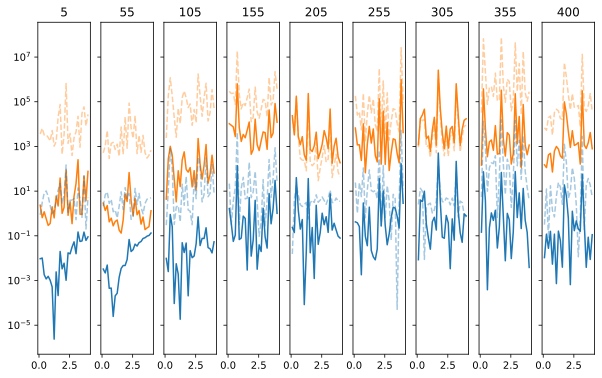

In [32]:


fig,axs = plt.subplots(figsize=(10,6),ncols = len(lengths), sharey=True)

for length in lengths:
    ax = axs[lengths==length][0]
    ax.set_title(f"{length}")
    df = results_df[results_df.sequence_length == length]
    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()
    ax.plot(theta, bias,"C0", label="squared bias")
    ax.semilogy(theta, variance , "C1", label="variance")
    ax.plot(theta, ut_bias,"C0--", label="untrained squared bias",alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance",alpha=0.4)

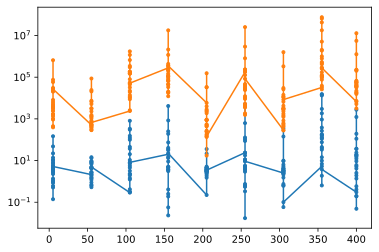

In [33]:
df = results_df[results_df.theta == results_df.theta.unique()[9]]
df = results_df #[results_df.theta == results_df.theta.unique()[9]]
bias = df.trained_squared_bias
variance = df.trained_variance
ut_bias = df.untrained_squared_bias
ut_variance = df.untrained_variance
lengths = df.sequence_length.to_numpy()

fig,ax = plt.subplots(figsize=(6,4))
ax.plot(lengths,  np.abs(bias - ut_bias), "C0.-",label="squared bias")
ax.semilogy(lengths, np.abs(variance - ut_variance), "C1.-",label="variance")

#ax.plot(lengths, ut_bias, "C0+--",label="untrained squared bias")
#ax.semilogy(lengths, ut_variance, "C1+--",label="untrained variance")

In [34]:
# Load variance prediction results (coefficient 1)
variance_results_path = "../experiments/predictive_test_results_coef1.csv"
variance_results_df = pd.read_csv(variance_results_path)

print(f"Variance prediction results shape: {variance_results_df.shape}")
variance_results_df.head()

Variance prediction results shape: (225, 10)


,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,282.076384,0.186848,282.263232,5227.465853,305.045929,5532.511782,5000
1,theta_sweeps,5,0.2625,36.476502,0.114622,36.591124,713.415390,96.631577,810.046967,5000
2,theta_sweeps,5,0.4250,12.160117,0.069657,12.229774,268.114453,50.653019,318.767471,5000
3,theta_sweeps,5,0.5875,5.462165,0.051723,5.513888,135.601838,32.396900,167.998738,5000
4,theta_sweeps,5,0.7500,2.835090,0.040754,2.875844,78.251188,23.266569,101.517757,5000


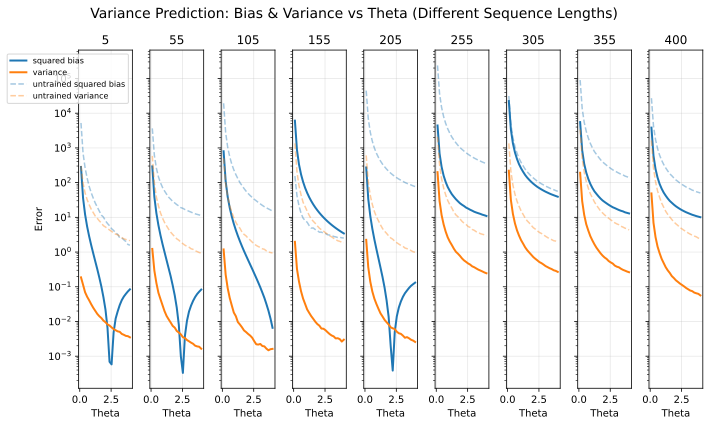

In [35]:
# Plot bias and variance vs theta for different sequence lengths (Variance Prediction)
lengths_var = variance_results_df.sequence_length.unique()

fig, axs = plt.subplots(figsize=(10, 6), ncols=len(lengths_var), sharey=True)
fig.suptitle("Variance Prediction: Bias & Variance vs Theta (Different Sequence Lengths)", fontsize=14)

for i, length in enumerate(lengths_var):
    ax = axs[i] if len(lengths_var) > 1 else axs
    ax.set_title(f"{length}")
    df = variance_results_df[variance_results_df.sequence_length == length]
    
    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()
    
    ax.plot(theta, bias, "C0", label="squared bias", linewidth=2)
    ax.semilogy(theta, variance, "C1", label="variance", linewidth=2)
    ax.plot(theta, ut_bias, "C0--", label="untrained squared bias", alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance", alpha=0.4)
    
    ax.set_xlabel("Theta")
    if i == 0:
        ax.set_ylabel("Error")
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()